# Tinker OMR Training Visualization

可视化 Tinker 训练过程中的 loss 曲线

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

## 1. 加载训练日志

In [2]:
# 加载 metrics.jsonl
log_path = Path("../logs/tinker_omr_large/metrics.jsonl")

records = []
with open(log_path, 'r') as f:
    for line in f:
        if line.strip():
            records.append(json.loads(line))

df = pd.DataFrame(records)
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"Total records: {len(df)}")
print(f"Steps: {df['step'].min()} - {df['step'].max()}")
df.head()

Total records: 978
Steps: 0 - 977


,step,train_loss,timestamp,val_loss
0,0,6.192584,2025-12-24 17:23:52.335205,5.281791
1,1,5.228578,2025-12-24 17:24:04.139211,NaN
2,2,4.714694,2025-12-24 17:24:08.815994,NaN
3,3,4.357379,2025-12-24 17:24:14.095196,NaN
4,4,3.943356,2025-12-24 17:24:18.767728,NaN


## 2. Training Loss 曲线

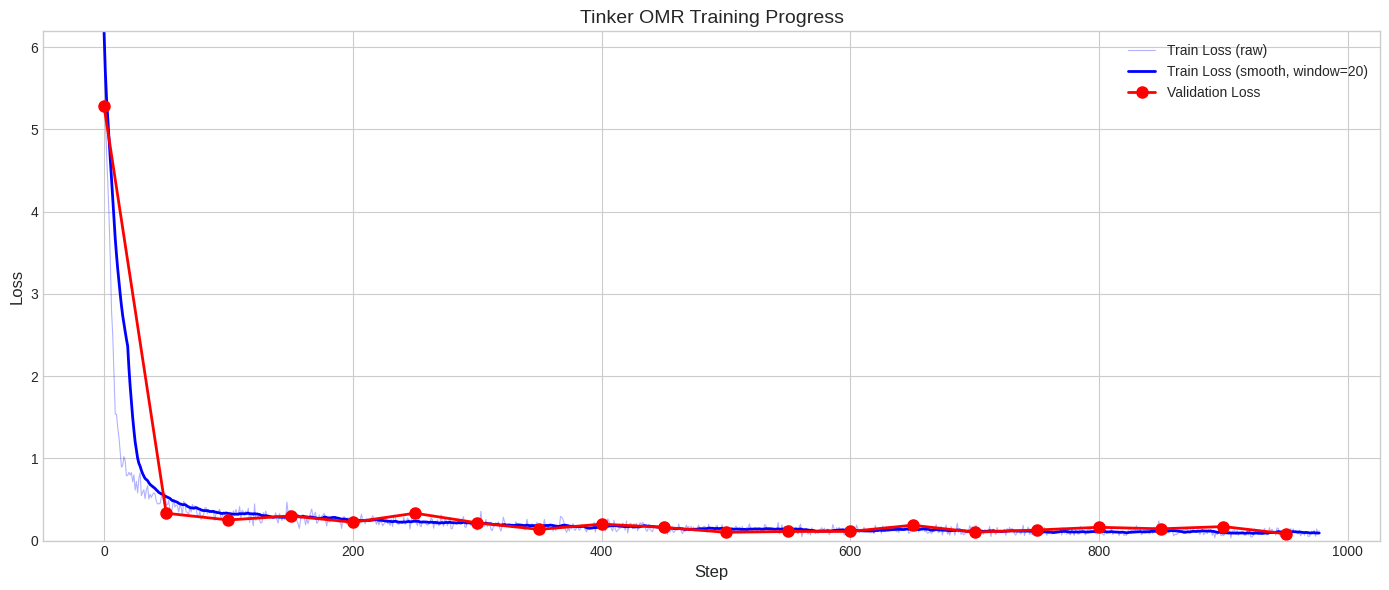

In [3]:
fig, ax = plt.subplots(figsize=(14, 6))

# Training loss
ax.plot(df['step'], df['train_loss'], 'b-', alpha=0.3, linewidth=0.8, label='Train Loss (raw)')

# Smoothed training loss (rolling average)
window = 20
df['train_loss_smooth'] = df['train_loss'].rolling(window=window, min_periods=1).mean()
ax.plot(df['step'], df['train_loss_smooth'], 'b-', linewidth=2, label=f'Train Loss (smooth, window={window})')

# Validation loss
val_df = df[df['val_loss'].notna()]
ax.plot(val_df['step'], val_df['val_loss'], 'ro-', markersize=8, linewidth=2, label='Validation Loss')

ax.set_xlabel('Step', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Tinker OMR Training Progress', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(0, max(df['train_loss'].max(), 1.0))

plt.tight_layout()
plt.show()

## 3. Loss 对数尺度

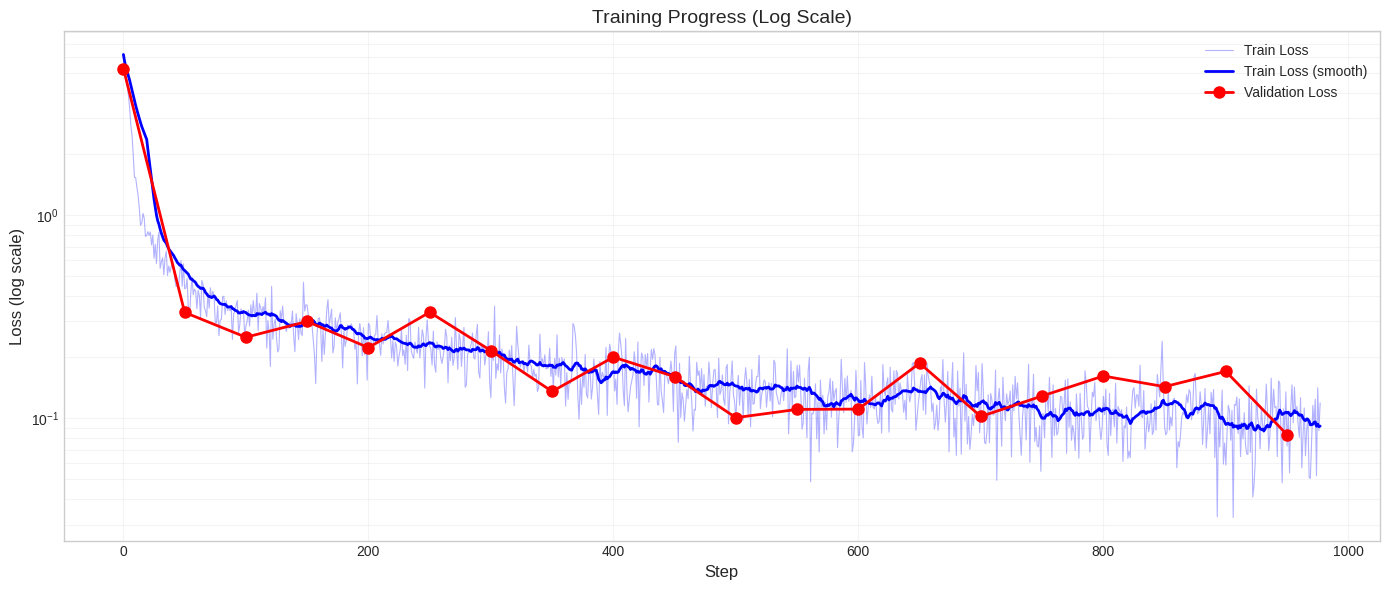

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.semilogy(df['step'], df['train_loss'], 'b-', alpha=0.3, linewidth=0.8, label='Train Loss')
ax.semilogy(df['step'], df['train_loss_smooth'], 'b-', linewidth=2, label='Train Loss (smooth)')
ax.semilogy(val_df['step'], val_df['val_loss'], 'ro-', markersize=8, linewidth=2, label='Validation Loss')

ax.set_xlabel('Step', fontsize=12)
ax.set_ylabel('Loss (log scale)', fontsize=12)
ax.set_title('Training Progress (Log Scale)', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

## 4. Validation Loss 变化

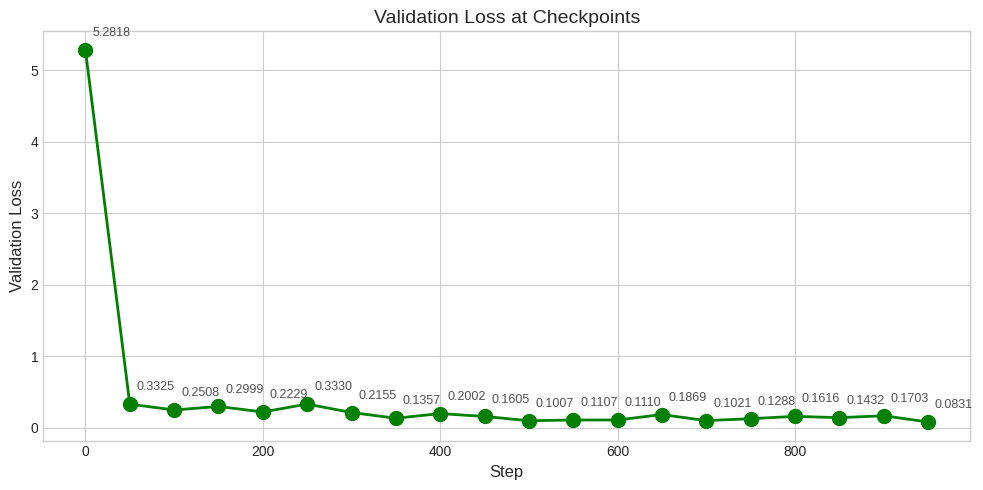


Validation Loss Summary:
 step  val_loss
    0  5.281791
   50  0.332467
  100  0.250793
  150  0.299939
  200  0.222914
  250  0.332975
  300  0.215486
  350  0.135653
  400  0.200228
  450  0.160471
  500  0.100747
  550  0.110670
  600  0.111025
  650  0.186870
  700  0.102119
  750  0.128818
  800  0.161587
  850  0.143170
  900  0.170300
  950  0.083054


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(val_df['step'], val_df['val_loss'], 'go-', markersize=10, linewidth=2)

# 标注每个点的值
for _, row in val_df.iterrows():
    ax.annotate(f"{row['val_loss']:.4f}", 
                xy=(row['step'], row['val_loss']),
                xytext=(5, 10), textcoords='offset points',
                fontsize=9, alpha=0.8)

ax.set_xlabel('Step', fontsize=12)
ax.set_ylabel('Validation Loss', fontsize=12)
ax.set_title('Validation Loss at Checkpoints', fontsize=14)

plt.tight_layout()
plt.show()

# 打印 val loss 表格
print("\nValidation Loss Summary:")
print(val_df[['step', 'val_loss']].to_string(index=False))

## 5. 训练统计

In [6]:
# 计算训练时间
total_time = (df['timestamp'].max() - df['timestamp'].min()).total_seconds()
hours = int(total_time // 3600)
minutes = int((total_time % 3600) // 60)

# 统计信息
stats = {
    'Total Steps': len(df),
    'Training Time': f"{hours}h {minutes}m",
    'Initial Train Loss': f"{df['train_loss'].iloc[0]:.4f}",
    'Final Train Loss': f"{df['train_loss'].iloc[-1]:.4f}",
    'Min Train Loss': f"{df['train_loss'].min():.4f}",
    'Initial Val Loss': f"{val_df['val_loss'].iloc[0]:.4f}" if len(val_df) > 0 else 'N/A',
    'Final Val Loss': f"{val_df['val_loss'].iloc[-1]:.4f}" if len(val_df) > 0 else 'N/A',
    'Best Val Loss': f"{val_df['val_loss'].min():.4f}" if len(val_df) > 0 else 'N/A',
    'Loss Reduction': f"{(1 - df['train_loss'].iloc[-1] / df['train_loss'].iloc[0]) * 100:.1f}%"
}

print("=" * 40)
print("Training Statistics")
print("=" * 40)
for key, value in stats.items():
    print(f"{key:20s}: {value}")

Training Statistics
Total Steps         : 978
Training Time       : 2h 6m
Initial Train Loss  : 6.1926
Final Train Loss    : 0.1192
Min Train Loss      : 0.0325
Initial Val Loss    : 5.2818
Final Val Loss      : 0.0831
Best Val Loss       : 0.0831
Loss Reduction      : 98.1%


## 6. Loss 分布直方图

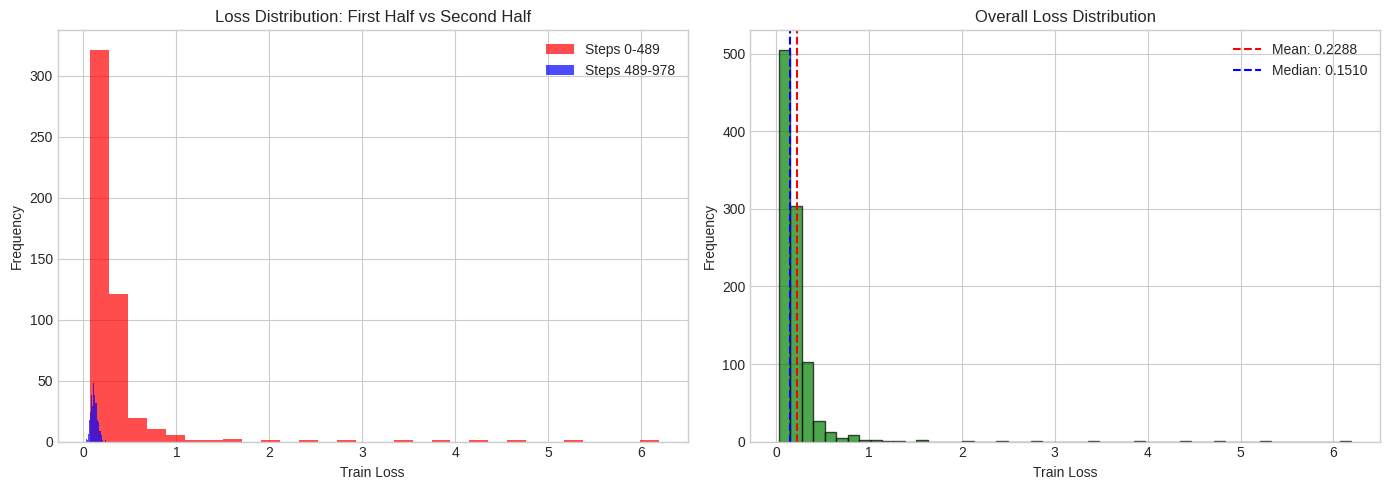

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 前半段 vs 后半段对比
mid = len(df) // 2
first_half = df['train_loss'].iloc[:mid]
second_half = df['train_loss'].iloc[mid:]

axes[0].hist(first_half, bins=30, alpha=0.7, label=f'Steps 0-{mid}', color='red')
axes[0].hist(second_half, bins=30, alpha=0.7, label=f'Steps {mid}-{len(df)}', color='blue')
axes[0].set_xlabel('Train Loss')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Loss Distribution: First Half vs Second Half')
axes[0].legend()

# 整体分布
axes[1].hist(df['train_loss'], bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1].axvline(df['train_loss'].mean(), color='red', linestyle='--', label=f"Mean: {df['train_loss'].mean():.4f}")
axes[1].axvline(df['train_loss'].median(), color='blue', linestyle='--', label=f"Median: {df['train_loss'].median():.4f}")
axes[1].set_xlabel('Train Loss')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Overall Loss Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. 训练速度分析

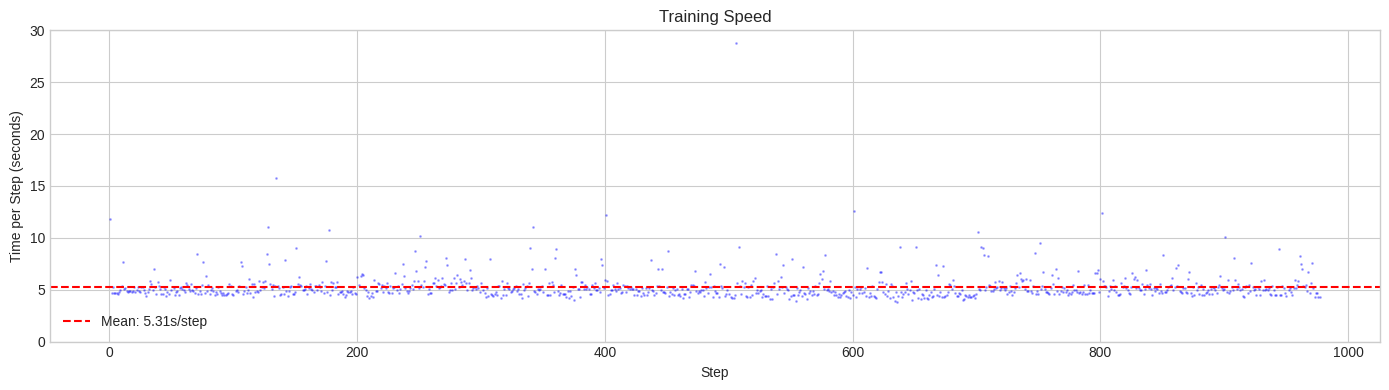

Average time per step: 5.31s
Steps per minute: 11.3


In [8]:
# 计算每个 step 的时间间隔
df['time_diff'] = df['timestamp'].diff().dt.total_seconds()

fig, ax = plt.subplots(figsize=(14, 4))

# 过滤掉异常值（如 validation 时的长间隔）
time_diff = df['time_diff'].dropna()
time_diff_filtered = time_diff[time_diff < 60]  # 只看 < 60s 的

ax.plot(df['step'].iloc[1:], df['time_diff'].iloc[1:], 'b.', alpha=0.3, markersize=2)
ax.axhline(time_diff_filtered.mean(), color='red', linestyle='--', 
           label=f"Mean: {time_diff_filtered.mean():.2f}s/step")

ax.set_xlabel('Step')
ax.set_ylabel('Time per Step (seconds)')
ax.set_title('Training Speed')
ax.set_ylim(0, 30)
ax.legend()

plt.tight_layout()
plt.show()

print(f"Average time per step: {time_diff_filtered.mean():.2f}s")
print(f"Steps per minute: {60 / time_diff_filtered.mean():.1f}")